Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['d2c-churn-part1-eda']
['data', 'output']
['churn_labels.csv', 'customers.csv', 'DATA_DICTIONARY.md', 'intervention_history.csv', 'orders.csv', 'rfm_modeling_snapshot.csv', 'STUDENT_FACING_PROBLEM_STATEMENT.md', 'support_tickets.csv', 'web_events_snapshot.csv']

 CUSTOMERS
(2400, 9)
Index(['customer_id', 'signup_date', 'city_tier', 'age_group',
       'acquisition_channel', 'loyalty_tier', 'preferred_category',
       'skin_type', 'marketing_consent'],
      dtype='object')
  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram   
1   CUST00002  2025-06-01    Tier 2     25-34         Marketplace   
2   CUST00003  2025-03-08    Tier 1     25-34          Influencer   
3   CUST00004  2025-04-15    Tier 3     25-34       Google Search   
4   CUST00005  2024-08-21    Tier 3     35-44 

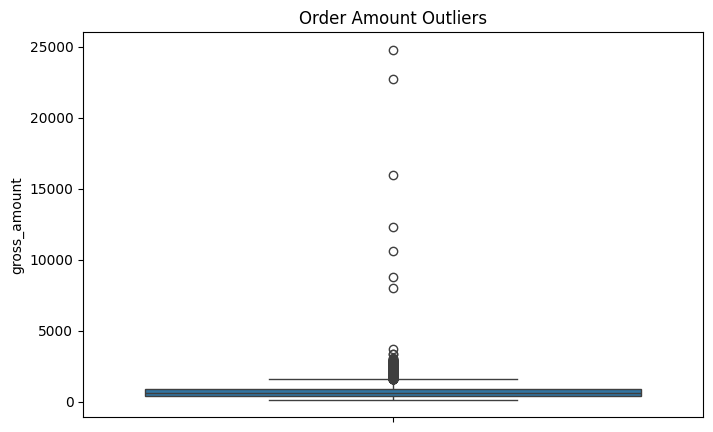

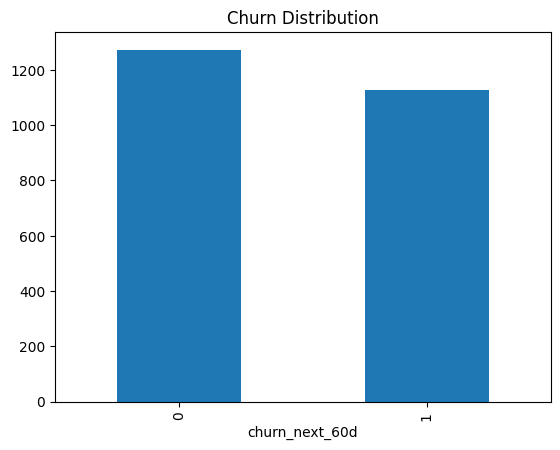

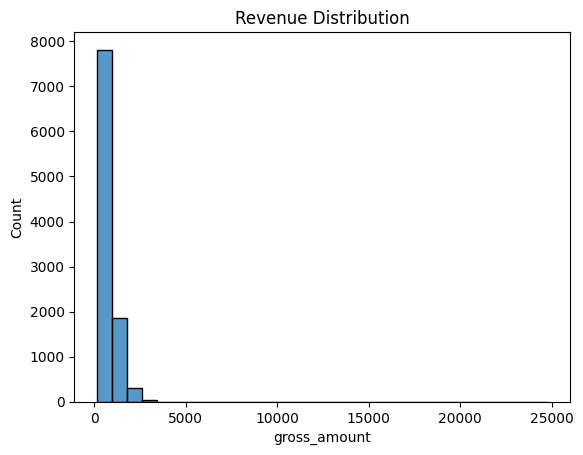

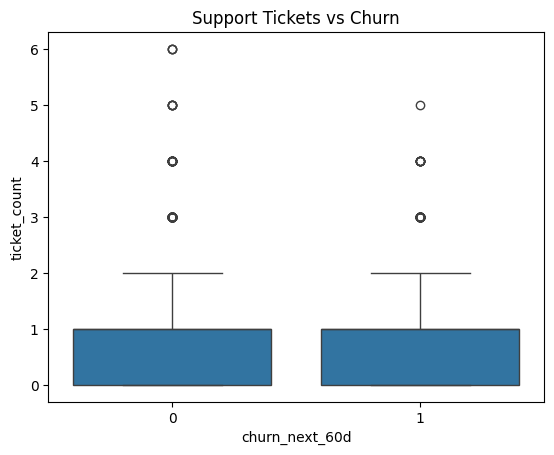

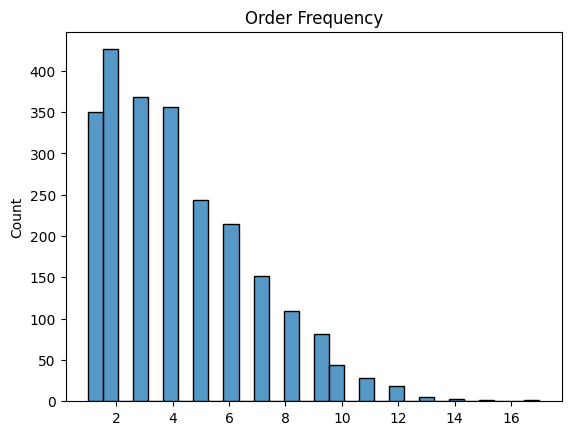

['customer_id', 'snapshot_date', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket']


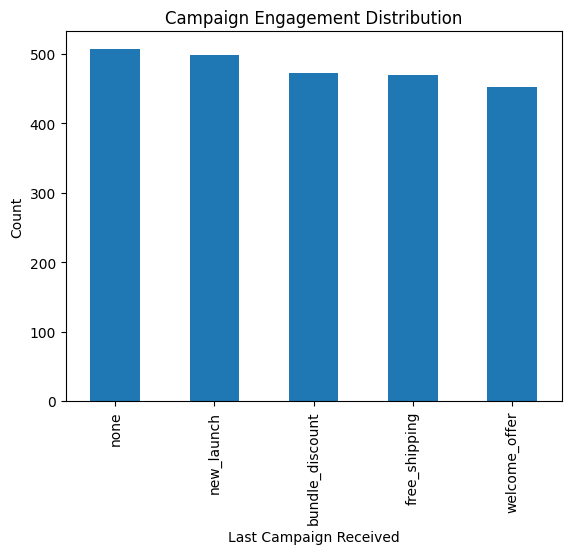

['customer_id', 'snapshot_date', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket']


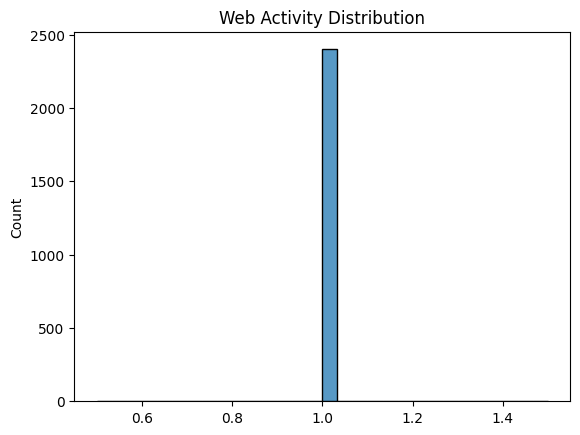

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


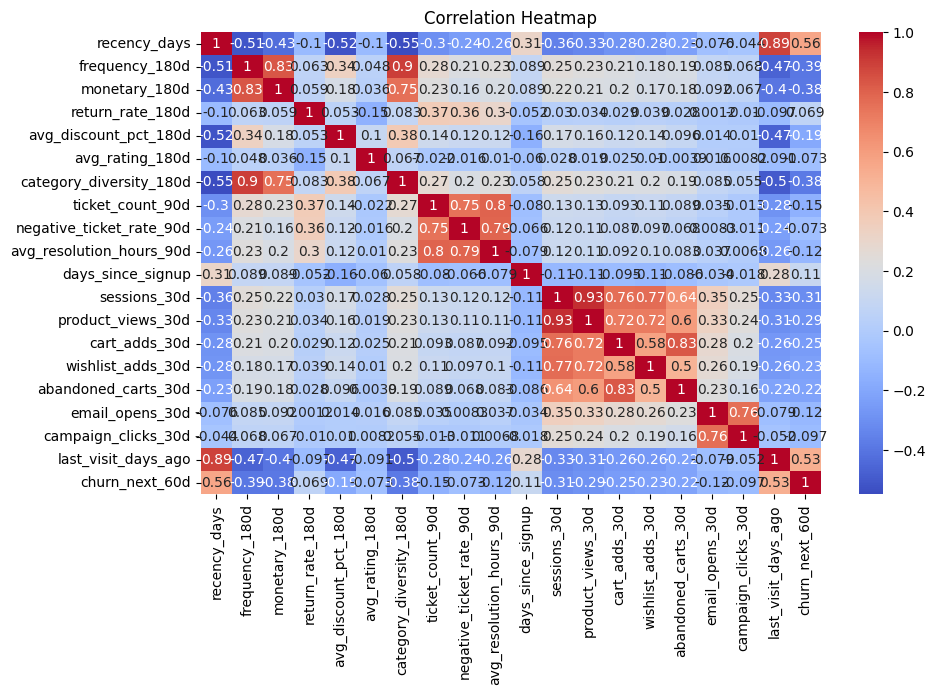

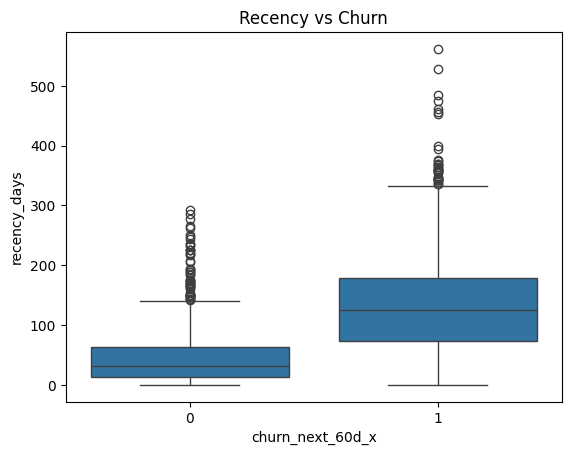

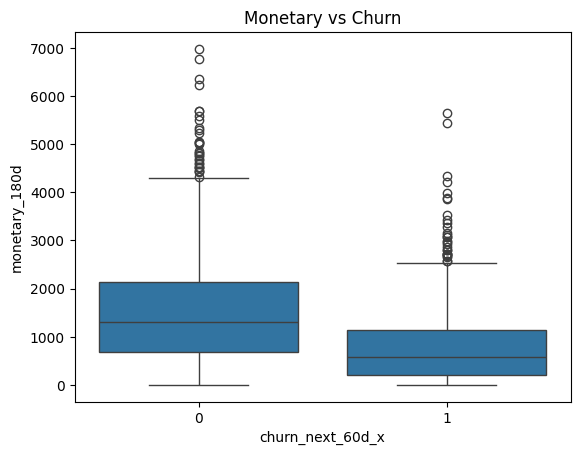

0
2024-01-09 00:00:00 2025-11-29 00:00:00
Customers duplicate customer_id: 0
Orders missing customers: 0
Tickets missing customers: 0


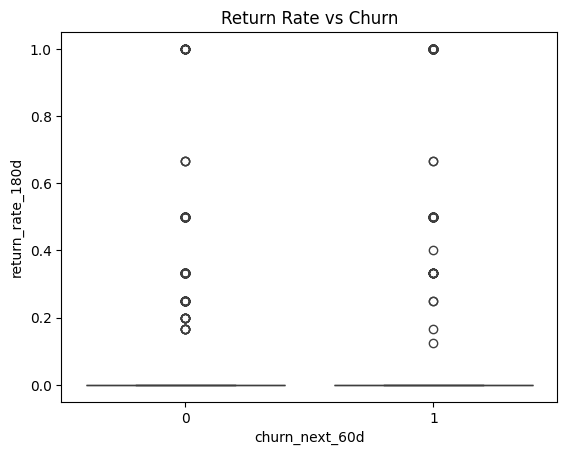

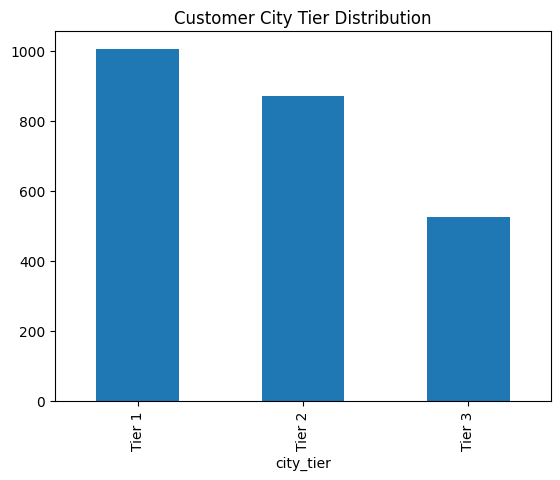

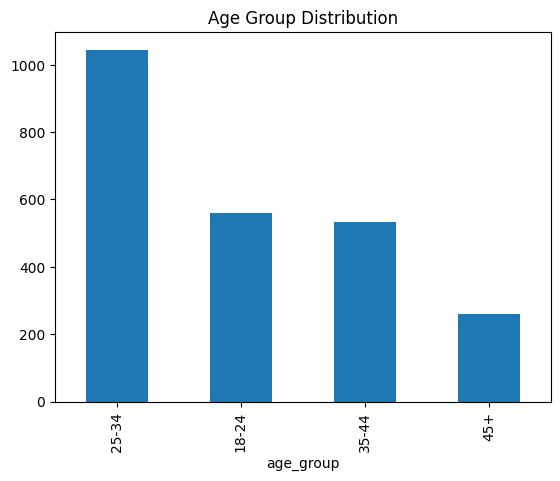

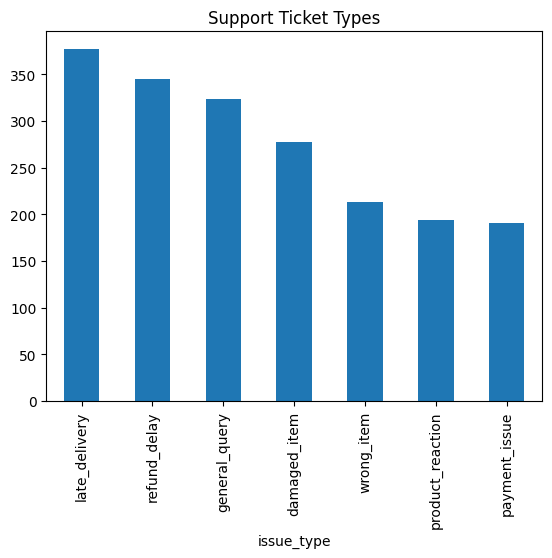

EDA and data quality audit completed successfully.


In [15]:

# import liabraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

#Load dataset
import os

from google.colab import drive
drive.mount('/content/drive')

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/'))

import os

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part1-eda/'))


import os

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part1-eda/data/'))


BASE_PATH = "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part1-eda/data/"

customers = pd.read_csv(BASE_PATH + "customers.csv")

orders = pd.read_csv(BASE_PATH + "orders.csv")

tickets = pd.read_csv(BASE_PATH + "support_tickets.csv")

events = pd.read_csv(BASE_PATH + "web_events_snapshot.csv")

labels = pd.read_csv(BASE_PATH + "churn_labels.csv")

campaigns = pd.read_csv(BASE_PATH + "intervention_history.csv")

rfm_snapshot = pd.read_csv(BASE_PATH + "rfm_modeling_snapshot.csv")

# Dataset inspection

datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "events": events,
    "labels": labels,
    "campaigns": campaigns
}

for name, df in datasets.items():
    print("\n", name.upper())
    print(df.shape)
    print(df.columns)
    print(df.head())
    print(df.info())


#Missing values

for name, df in datasets.items():
    print("\nMissing values in", name)
    print(df.isnull().sum())


#Duplicate Records

for name, df in datasets.items():
    print(name, df.duplicated().sum())


#Invalid Values

orders[orders['gross_amount'] < 0]


#Outlier Detection

plt.figure(figsize=(8,5))

sns.boxplot(y=orders['gross_amount'])

plt.title("Order Amount Outliers")


plt.show()


#  Join Datasets

merged = orders.merge(customers, on='customer_id', how='left')


#CHART 1 — Churn Distribution

labels['churn_next_60d'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.show()


# CHART 2 — Revenue Distribution

sns.histplot(orders['gross_amount'], bins=30)
plt.title('Revenue Distribution')
plt.show()


# CHART 3 — Support Tickets vs Churn

ticket_summary = tickets.groupby('customer_id').size().reset_index(name='ticket_count')

analysis = labels.merge(ticket_summary, on='customer_id', how='left')
analysis['ticket_count'] = analysis['ticket_count'].fillna(0)

sns.boxplot(x='churn_next_60d', y='ticket_count', data=analysis)
plt.title('Support Tickets vs Churn')
plt.show()


# CHART 4 — Order Frequency

freq = orders.groupby('customer_id').size()

sns.histplot(freq, bins=30)
plt.title('Order Frequency')
plt.show()


# CHART 5 — Campaign Engagement

print(campaigns.columns.tolist())   # check available columns

# Remove extra spaces from column names
campaigns.columns = campaigns.columns.str.strip()

# Example using 'opened' column
# Replace 'opened' with the actual column name if different

campaigns['last_campaign_received'].value_counts().plot(kind='bar')

plt.title('Campaign Engagement Distribution')
plt.xlabel('Last Campaign Received')
plt.ylabel('Count')

plt.show()


print(campaigns.columns.tolist())

#CHART 6 — Web Activity

event_counts = events.groupby('customer_id').size()

sns.histplot(event_counts, bins=30)
plt.title('Web Activity Distribution')
plt.show()


#  CHURN PERCENTAGE

churn_percent = labels['churn_next_60d'].value_counts(normalize=True) * 100

print(churn_percent)


# HEATMAP

numeric_cols = rfm_snapshot.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

#RECENCY ANALYSIS

sns.boxplot(
    x=rfm_labels['churn_next_60d_x'],
    y=rfm_labels['recency_days']
)

plt.title("Recency vs Churn")

plt.show()

# MONETARY ANALYSIS

sns.boxplot(
    x=rfm_labels['churn_next_60d_x'],
    y=rfm_labels['monetary_180d']
)

plt.title("Monetary vs Churn")

plt.show()


# DATE CONSISTENCY CHECK

orders.columns

# Convert to datetime safely
orders['order_date'] = pd.to_datetime(
    orders['order_date'],
    errors='coerce'
)

# Check invalid dates
print(orders['order_date'].isnull().sum())

# Show min and max dates
print(
    orders['order_date'].min(),
    orders['order_date'].max()
)



#Join/Key Issues Check

# JOIN / KEY ISSUES

print("Customers duplicate customer_id:",
      customers['customer_id'].duplicated().sum())

print("Orders missing customers:",
      orders[~orders['customer_id'].isin(customers['customer_id'])].shape[0])

print("Tickets missing customers:",
      tickets[~tickets['customer_id'].isin(customers['customer_id'])].shape[0])


#Return / Refund Behaviour Analysis

# RETURN / REFUND ANALYSIS

if 'return_rate_180d' in rfm_snapshot.columns:

    sns.boxplot(
        x='churn_next_60d',
        y='return_rate_180d',
        data=rfm_snapshot
    )

    plt.title("Return Rate vs Churn")

    plt.show()


  # Customer Demographics Analysis

  # CUSTOMER DEMOGRAPHICS

customers['city_tier'].value_counts().plot(kind='bar')

plt.title("Customer City Tier Distribution")

plt.show()


customers['age_group'].value_counts().plot(kind='bar')

plt.title("Age Group Distribution")

plt.show()


# Support Ticket Issue Analysis


# SUPPORT TICKET ANALYSIS

if 'issue_type' in tickets.columns:

    tickets['issue_type'].value_counts().plot(kind='bar')

    plt.title("Support Ticket Types")

    plt.show()


    print("EDA and data quality audit completed successfully.")



#Potential Leakage Columns

leakage_cols = [
    'churn_next_60d',
    'snapshot_date',
    'split'
]

print("Potential leakage columns:", leakage_cols)

# FIVE CHURN-RISK HYPOTHESES

* Hypothesis 1

  Customers with high recency are more likely to churn.

  Evidence: Recency vs churn boxplot shows churned users had larger recency_days.

* Hypothesis 2

  Customers with more support tickets churn more frequently.

  Evidence: Ticket count boxplot.

* Hypothesis 3

  Lower monetary customers churn more.

  Evidence: Monetary analysis chart.

* Hypothesis 4

  Customers with high return rates are more likely to churn.

  Evidence: Return rate analysis.

* Hypothesis 5

  Low web engagement customers churn more.

  Evidence: Web activity histogram.